# pydisort_riccati_jax: a quick tour

[`pydisort_riccati_jax`](./riccati_solver.md) is a **differentiable** forward solver for the 1-D Radiative Transfer Equation in an atmosphere whose single-scattering albedo $\omega(\tau)$ and phase function $g_l(\tau)$ vary **continuously** with optical depth. It is the radiative-transfer link in the effective-radius retrieval chain

$$ r_e(\tau)\to\text{Mie}\to\big(\omega(\tau),\,\text{Leg\_coeffs}(\tau)\big)\to\textbf{pydisort\_riccati\_jax}\to u^{+}(\tau{=}0,\mu,\phi). $$

It is a companion to [PythonicDISORT](https://pythonic-disort.readthedocs.io/en/latest/) (the eigendecomposition solver), reuses its conventions, and is validated against it. This notebook walks through the public API on a $\tau$-varying cloud; the companion [`riccati_solver_VOCALS_retrieval.ipynb`](./riccati_solver_VOCALS_retrieval.ipynb) wires in `miejax_lite` for a VOCALS-REx retrieval.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

repo_root = Path.cwd().parent          # docs/ -> repo root
sys.path.insert(0, str(repo_root / 'src'))
sys.path.insert(0, str(repo_root / 'tests'))   # for _helpers

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from math import pi

from pydisort_riccati_jax import pydisort_riccati_jax, interpolate

## 1. A $\tau$-varying ('adiabatic') cloud

$\omega$ and the asymmetry parameter $g$ ramp linearly from cloud top ($\tau{=}0$) to base. The phase function is Henyey–Greenstein, $g_l(\tau)=g(\tau)^l$. The optical properties are passed as **callables** of $\tau$ — this is exactly the interface the Mie front-end fills.

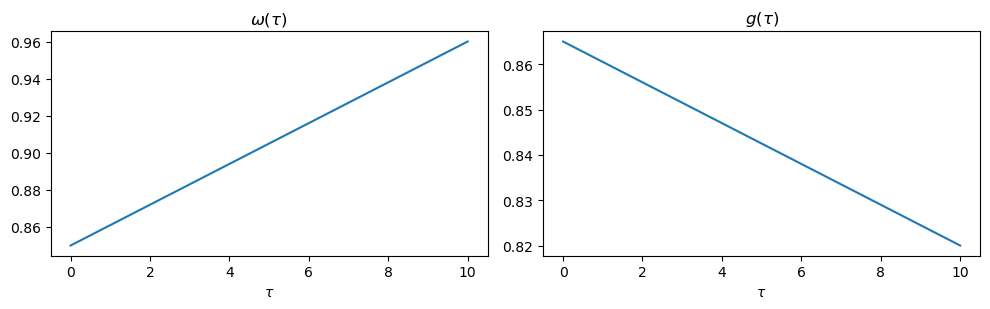

In [2]:
tau_bot = 10.0                       # cloud optical thickness
NQuad   = 16                         # quadrature streams (even, >= 6)
NLeg    = NQuad

omega_func = lambda tau: 0.85 + (0.96 - 0.85) * tau / tau_bot
g_func     = lambda tau: 0.865 + (0.820 - 0.865) * tau / tau_bot
Leg_coeffs_func = lambda tau: g_func(tau) ** jnp.arange(NLeg)

tau_plot = jnp.linspace(0, tau_bot, 200)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(tau_plot, [omega_func(t) for t in tau_plot]); ax[0].set_title(r'$\omega(\tau)$')
ax[1].plot(tau_plot, [g_func(t) for t in tau_plot]);     ax[1].set_title(r'$g(\tau)$')
for a in ax: a.set_xlabel(r'$\tau$')
plt.tight_layout()

## 2. Solve for the ToA upwelling field

A single call returns the upwelling quadrature cosines, the upward flux, the zeroth Fourier mode $u_0$, an azimuthally-resolved radiance closure $u^{+}(\tau{=}0,\phi)$, and the adaptive step grid. Everything is **upwelling-only** ($N=$ `NQuad // 2`).

In [3]:
mu0, I0, phi0 = 0.5, 1.0, 0.0        # solar geometry / beam intensity
BDRF = [0.05 / pi]                   # Lambertian ocean, albedo 0.05

mu_arr_pos, flux_up, u0_ToA, u_ToA_func, tau_grid = pydisort_riccati_jax(
    tau_bot, omega_func, Leg_coeffs_func, NQuad, mu0, I0, phi0,
    tol=1e-3, BDRF_Fourier_modes=BDRF,   # float32-safe; tol<=1e-4 max-steps on thick tau
)

print('upward flux at ToA :', flux_up)
print('adaptive steps     :', len(tau_grid) - 1)
print('u+ at phi0         :', np.asarray(u_ToA_func(phi0)))

upward flux at ToA : 0.07753388
adaptive steps     : 30
u+ at phi0         : [0.32895696 0.23170167 0.09135401 0.11646995 0.03144183 0.03936206
 0.02439661 0.00670238]


## 3. Validate against PythonicDISORT

`pydisort` solves piecewise-constant layers exactly. Approximating the continuous profile with more and more layers (midpoint rule) must converge toward the Riccati solution at $O(h^2)$. The helper `multilayer_pydisort_toa_full_phi` runs that reference.

In [4]:
from _helpers import multilayer_pydisort_toa_full_phi, PHI_VALUES

N = NQuad // 2
u_ric = np.column_stack([np.asarray(u_ToA_func(p))[:N] for p in PHI_VALUES])

def disort_err(NLayers):
    _, _, uf = multilayer_pydisort_toa_full_phi(
        tau_bot, omega_func, Leg_coeffs_func, NLayers, NQuad, NLeg,
        mu0, I0, phi0, BDRF_Fourier_modes=BDRF)
    u_dis = np.column_stack([uf(0, p)[:N] for p in PHI_VALUES])
    return np.max(np.abs(u_dis - u_ric)) / np.max(np.abs(u_ric))

e50, e500 = disort_err(50), disort_err(500)
print(f'rel. err  50 layers : {e50:.2e}')
print(f'rel. err 500 layers : {e500:.2e}')
print(f'convergence ratio   : {e50 / e500:.1f}  (~100 expected for 10x refinement)')

rel. err  50 layers : 1.85e-03
rel. err 500 layers : 1.36e-03
convergence ratio   : 1.4  (~100 expected for 10x refinement)


## 4. Interpolate to an arbitrary viewing angle

Radiances are returned at the quadrature cosines `mu_arr_pos`. For a satellite viewing geometry we need an arbitrary $\mu\in(0,1]$: `interpolate` does barycentric Lagrange interpolation in $\mu$ at ToA (the analog of `PythonicDISORT.subroutines.interpolate`).

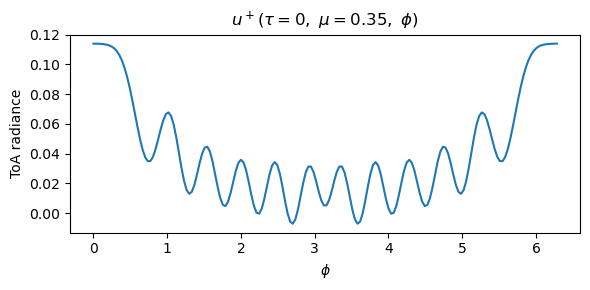

In [5]:
u_interp = interpolate(u_ToA_func, mu_arr_pos)

mu_obs = 0.35                        # cosine of viewing zenith angle
phi = jnp.linspace(0, 2 * pi, 180)
radiance = u_interp(mu_obs, phi)     # (len(phi),)

plt.figure(figsize=(6, 3))
plt.plot(phi, radiance)
plt.xlabel(r'$\phi$'); plt.ylabel('ToA radiance')
plt.title(fr'$u^+(\tau=0,\ \mu={mu_obs},\ \phi)$')
plt.tight_layout()

## 5. Differentiability — the point of the JAX rewrite

`u0_ToA`, `u_ToA_func`, and `u_interp` are JAX-traceable, so retrieval Jacobians come from autodiff. Here the sensitivity of a ToA radiance to the viewing angle $\mu$ and azimuth $\phi$ (both checked in the test suite); the VOCALS notebook differentiates w.r.t. the $r_e(\tau)$ profile itself.

In [6]:
dI_dmu  = jax.grad(lambda mu:  u_interp(mu, pi / 4))(0.35)
dI_dphi = jax.grad(lambda phi: u_ToA_func(phi)[0])(pi / 4)
print('d(radiance)/d(mu)  =', float(dI_dmu))
print('d(radiance)/d(phi) =', float(dI_dphi))

d(radiance)/d(mu)  = 0.054322127252817154
d(radiance)/d(phi) = -0.01706782728433609


---
Next: [`riccati_solver_VOCALS_retrieval.ipynb`](./riccati_solver_VOCALS_retrieval.ipynb) — drive the solver from `miejax_lite` optics and compute a retrieval Jacobian $\partial u^{+}/\partial r_e$ for VOCALS-REx.